In [1]:
import os
import random
import numpy as np
import torch

def set_seed(seed: int = 42):
    # Python built-in random
    random.seed(seed)
    
    # Numpy
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    
    # For reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Hash-based operations
    os.environ["PYTHONHASHSEED"] = str(seed)

# Call this once at the very top of your notebook
set_seed(42)
import random

# --- TAMBAHKAN BLOK INI UNTUK REPRODUCIBILITY ---
SEED = 42

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # jika menggunakan multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

In [2]:
# ===================================================================
# === 1. IMPORT LIBRARY ===
# ===================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import os
import pandas as pd
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, accuracy_score
import cv2
import timm
from pathlib import Path
from tqdm.auto import tqdm

# ===================================================================
# === 2. KONFIGURASI DAN SETUP ===
# ===================================================================
# Direktori (Hanya Train)
TRAIN_DIR = "/kaggle/input/datasets/mdzkhkm/dataset-makanan/makanan"

# Konfigurasi Model dan Training
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 518
BATCH_SIZE = 8
NUM_WORKERS = os.cpu_count()

# --- HYPERPARAMETER UNTUK GRADUAL UNFREEZING ---
EPOCHS_S1 = 3
LR_S1 = 3e-4
EPOCHS_S2 = 5
LR_S2 = 5e-5
EPOCHS_S3 = 12
LR_S3 = 1.59e-06 

# Statistik ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"Menggunakan device: {DEVICE}")
print(f"Ukuran gambar: {IMG_SIZE}x{IMG_SIZE}, Batch Size: {BATCH_SIZE}")

# ===================================================================
# === 3. FUNGSI DAN KELAS HELPER ===
# ===================================================================
def convert_path_to_df(dataset):
    image_dir = Path(dataset)
    
    # 1. Tentukan ekstensi gambar yang valid (dalam huruf kecil)
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff'}

    # 2. Ambil semua file path terlebih dahulu
    all_filepaths = list(image_dir.glob(r'**/*.*'))
    
    # 3. Filter daftar file, hanya ambil yang ekstensinya ada di set
    filepaths = [p for p in all_filepaths if p.suffix.lower() in image_extensions]
    
    # Cek jika tidak ada gambar yang ditemukan
    if not filepaths:
        print(f"Peringatan: Tidak ada file gambar yang ditemukan di {image_dir}")
        return pd.DataFrame(columns=['Filepath', 'Label'])

    # 4. Buat DataFrame
    labels = [p.parts[-2] for p in filepaths]
    filepaths = pd.Series(filepaths, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')
    
    return pd.concat([filepaths, labels], axis=1)

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_column, label_column=None, transform=None):
        self.dataframe = dataframe
        self.image_column = image_column
        self.label_column = label_column
        self.transform = transform
        
    def __len__(self): 
        return len(self.dataframe)
        
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx][self.image_column]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform: 
            image = self.transform(image)
            
        if self.label_column:
            label = self.dataframe.iloc[idx][self.label_column]
            return image, torch.tensor(label, dtype=torch.long)
            
        return image

class DualTransformDataset(Dataset):
    def __init__(self, dataframe, image_column, label_column, transform_main, transform_extra):
        self.dataframe = dataframe
        self.image_column = image_column
        self.label_column = label_column
        self.transform_main = transform_main
        self.transform_extra = transform_extra

    def __len__(self):
        # Gandakan ukuran dataset (dua versi per gambar)
        return len(self.dataframe) * 2

    def __getitem__(self, idx):
        # Tentukan apakah pakai augmentasi utama atau tambahan
        base_idx = idx // 2
        use_extra = idx % 2 == 1

        row = self.dataframe.iloc[base_idx]
        img_path = row[self.image_column]
        label = torch.tensor(row[self.label_column], dtype=torch.long)

        image = Image.open(img_path).convert('RGB')

        if use_extra:
            image = self.transform_extra(image)
        else:
            image = self.transform_main(image)

        return image, label

class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        
    def __call__(self, img):
        img_np = np.array(img)
        img_lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2Lab)
        l, a, b = cv2.split(img_lab)
        l_clahe = self.clahe.apply(l)
        img_lab_clahe = cv2.merge((l_clahe, a, b))
        img_rgb_clahe = cv2.cvtColor(img_lab_clahe, cv2.COLOR_Lab2RGB)
        return Image.fromarray(img_rgb_clahe)

# ===================================================================
# === 4. PERSIAPAN DATA DAN SPLITTING TETAP ===
# ===================================================================
print("\n" + "="*50)
print("Memuat dan mempersiapkan data training...")

# --- Langkah 4.1: Memuat data training ---
train_df = convert_path_to_df(TRAIN_DIR)
print(f"Total gambar ditemukan: {len(train_df)}")

# --- Langkah 4.2: Pemetaan Label ---
label_mapping = {
    "Ayam Bakar": 0, "Ayam Betutu": 1, "Ayam Goreng": 2, "Ayam Pop": 3,
    "Bakso": 4, "Coto Makassar": 5, "Gado Gado": 6, "Gudeg": 7,
    "Nasi Goreng": 8, "Pempek": 9, "Rawon": 10, "Rendang": 11,
    "Sate Madura": 12, "Sate Padang": 13, "Soto": 14
}

train_df['Label'] = train_df['Label'].map(label_mapping)

# Drop baris yang labelnya tidak ada di mapping (untuk keamanan)
train_df = train_df.dropna(subset=['Label'])
train_df['Label'] = train_df['Label'].astype(int)

# --- Langkah 4.3: Split Data ---
train_split, val_split = train_test_split(
    train_df, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_df['Label']
)

# Reset index agar rapi
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

print(f"Ukuran set training: {len(train_split)}")
print(f"Ukuran set validasi: {len(val_split)}")
print("="*50 + "\n")

# --- Langkah 4.4: Augmentasi dan DataLoaders ---
train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD)
])

# Transform tambahan: rotasi 90° kiri/kanan
train_transform_extra = transforms.Compose([
    CLAHETransform(),
    transforms.RandomChoice([
        transforms.RandomRotation((90, 90)),
        transforms.RandomRotation((-90, -90))
    ]),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = DualTransformDataset(
    train_split,
    image_column='Filepath',
    label_column='Label',
    transform_main=train_transform,
    transform_extra=train_transform_extra
)

val_dataset = CustomDataset(val_split, 'Filepath', 'Label', val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True)

# Hitung Class Weights untuk menangani imbalance data
class_weights = compute_class_weight("balanced", classes=np.unique(train_split["Label"]), y=train_split["Label"])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)


# ===================================================================
# === 5. DEFINISI MODEL ===
# ===================================================================

# --- MODEL BARU: SINGLE DINOV2 ---
class SingleDINOv2Model(nn.Module):
    def __init__(self, num_classes=5): 
        super().__init__()
        self.backbone = timm.create_model(
            "vit_base_patch14_dinov2", 
            pretrained=True, 
            num_classes=num_classes 
        )
    def forward(self, x):
        return self.backbone(x)

class SingleSwinModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model("swin_base_patch4_window7_224", pretrained=True, num_classes=num_classes)
    def forward(self, x):
        return self.backbone(x)

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Menggunakan device: cuda
Ukuran gambar: 518x518, Batch Size: 8

Memuat dan mempersiapkan data training...
Total gambar ditemukan: 4052
Ukuran set training: 3241
Ukuran set validasi: 811



## Model Dinov2


################################################################################
### MEMBANDINGKAN GAMBAR ASLI vs. AUGMENTASI ###
################################################################################

Menampilkan contoh untuk: Label 10 (dari /kaggle/input/datasets/mdzkhkm/dataset-makanan/makanan/Rawon/tvzrff_jpg.rf.958b2f584dcab22f03459a6a4d62b81e.jpg)


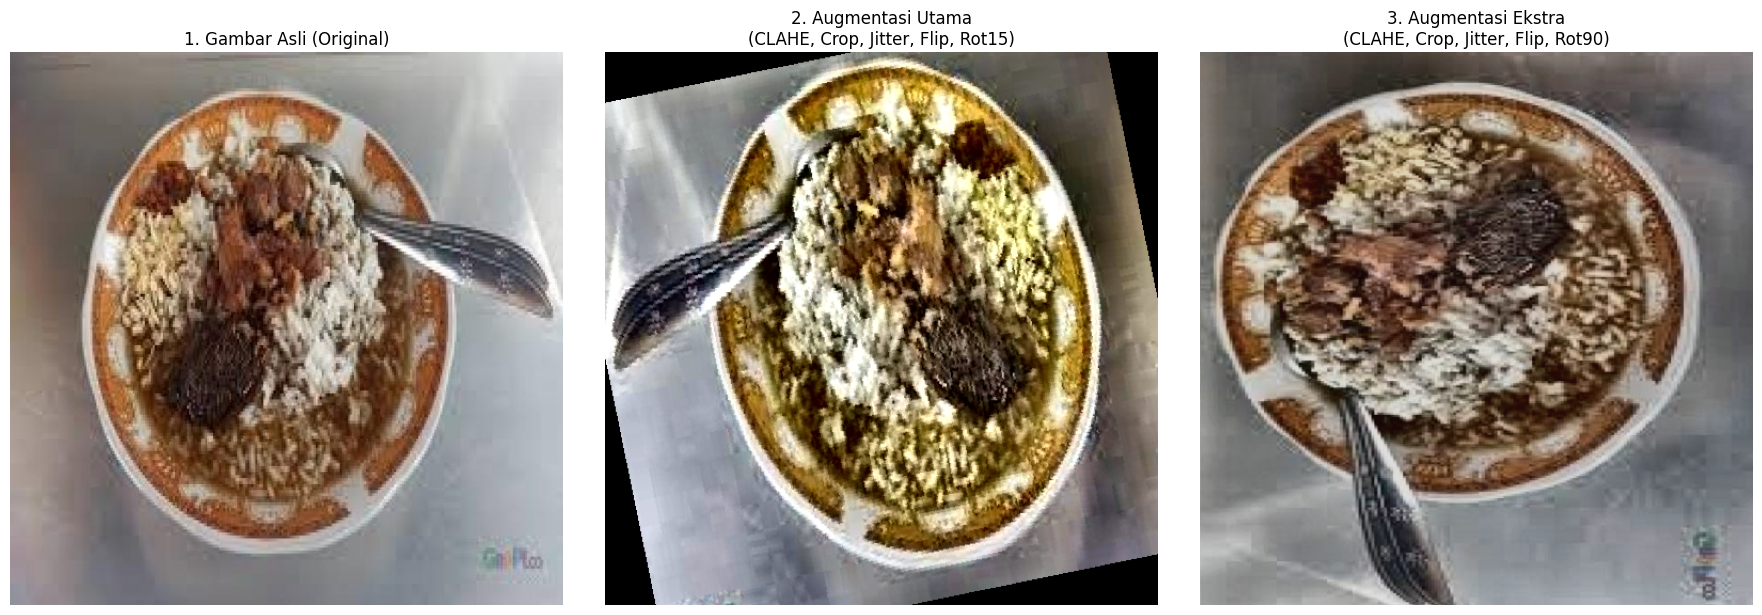

In [3]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
import random
import torch

# ===================================================================
# === BLOK VISUALISASI AUGMENTASI (Tambahan)
# ===================================================================
print("\n" + "#"*80)
print("### MEMBANDINGKAN GAMBAR ASLI vs. AUGMENTASI ###")
print("#"*80 + "\n")

def denormalize(tensor, mean, std):
    """
    Mengembalikan tensor gambar dari ternormalisasi (mean/std) ke [0, 1].
    """
    # Kloning agar tidak mengubah tensor asli
    tensor = tensor.clone() 
    
    # Buat tensor dari mean dan std, dan sesuaikan bentuknya
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    
    # Balikkan normalisasi: (tensor * std) + mean
    tensor.mul_(std).add_(mean)
    
    # Pastikan nilai tetap di [0, 1]
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

def visualize_augmentations(dataset_df, transform_main, transform_extra, mean, std):
    # 1. Ambil satu gambar acak dari dataset training Anda
    idx = random.randint(0, len(dataset_df) - 1)
    sample_row = dataset_df.iloc[idx]
    img_path = sample_row['Filepath']
    label = sample_row['Label']
    
    print(f"Menampilkan contoh untuk: Label {label} (dari {img_path})")

    # 2. Muat gambar asli
    original_pil_image = Image.open(img_path).convert('RGB')

    # 3. Terapkan transformasi
    # Ini akan menghasilkan tensor [C, H, W] yang sudah dinormalisasi
    transformed_main_tensor = transform_main(original_pil_image)
    transformed_extra_tensor = transform_extra(original_pil_image)

    # 4. De-normalisasi tensor agar bisa ditampilkan
    denorm_main_tensor = denormalize(transformed_main_tensor, mean, std)
    denorm_extra_tensor = denormalize(transformed_extra_tensor, mean, std)

    # 5. Konversi tensor kembali ke gambar PIL
    to_pil = ToPILImage()
    augmented_main_image = to_pil(denorm_main_tensor)
    augmented_extra_image = to_pil(denorm_extra_tensor)

    # 6. Plot semua 3 gambar
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    ax1.imshow(original_pil_image)
    ax1.set_title("1. Gambar Asli (Original)")
    ax1.axis('off')
    
    ax2.imshow(augmented_main_image)
    ax2.set_title("2. Augmentasi Utama\n(CLAHE, Crop, Jitter, Flip, Rot15)")
    ax2.axis('off')
    
    ax3.imshow(augmented_extra_image)
    ax3.set_title("3. Augmentasi Ekstra\n(CLAHE, Crop, Jitter, Flip, Rot90)")
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()

# --- Jalankan Visualisasi ---
try:
    # PERBAIKAN: Menggunakan nama variabel yang sesuai dengan blok sebelumnya
    visualize_augmentations(
        train_split, 
        train_transform,         
        train_transform_extra,
        IMAGENET_MEAN, 
        IMAGENET_STD
    )
except NameError as e:
    print(f"\n❌ GAGAL: Tidak bisa menjalankan visualisasi.")
    print(f"Error: {e}. Pastikan 'train_split' dan transforms sudah terdefinisi.")

In [4]:
# ===================================================================
# === 1. TAMBAHKAN IMPORT INI DI BAGIAN ATAS SKRIP ANDA ===
# ===================================================================
from timm.data.mixup import Mixup
import torch.nn.functional as F
from torch.optim.swa_utils import AveragedModel, SWALR
# ...

###################################################################################
### BLOK B: MELATIH MODEL DINOv2 (DENGAN MIXUP/CUTMIX + SWA)
###################################################################################
print("\n" + "#"*80)
print("### MEMULAI BLOK B: TRAINING MODEL DINOv2 (MIXUP/CUTMIX + SWA) ###")
print("#"*80 + "\n")

# B.1. Konfigurasi
IMG_SIZE = 518  # <-- ubah dari 224 ke 518 untuk DINOv2
BATCH_SIZE = 8
BEST_MODEL_NAME_DINO = "best_dinov2_standalone.pth"
BEST_MODEL_NAME_DINO_SWA = "best_dinov2_standalone_SWA.pth"
print(f"Menggunakan Ukuran Gambar: {IMG_SIZE}x{IMG_SIZE}, Batch Size: {BATCH_SIZE}")

# === TRANSFORM DATA ===
train_transform_main_518 = transforms.Compose([
    CLAHETransform(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_transform_extra_518 = transforms.Compose([
    CLAHETransform(),
    transforms.RandomChoice([transforms.RandomRotation((90, 90)), transforms.RandomRotation((-90, -90))]),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform_518 = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = DualTransformDataset(train_split, 'Filepath', 'Label', train_transform_main_518, train_transform_extra_518)
val_dataset = CustomDataset(val_split, 'Filepath', 'Label', val_test_transform_518)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True)


# B.3. Inisialisasi Model
class SingleDINOv2Model(nn.Module):
    def __init__(self, num_classes=5):  # num_classes = len(label_mapping)
        super().__init__()
        self.backbone = timm.create_model(
            "vit_base_patch14_dinov2",
            pretrained=True,
            num_classes=num_classes
        )
    def forward(self, x):
        return self.backbone(x)

model = SingleDINOv2Model(num_classes=len(label_mapping)).to(DEVICE)
print(f"Menggunakan model: vit_base_patch14_dinov2")

# --- INISIALISASI MODEL SWA ---
swa_model = AveragedModel(model).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
mixup_fn = Mixup(
    mixup_alpha=0.8,
    cutmix_alpha=1.0,
    prob=1.0,
    switch_prob=0.5,
    mode='batch',
    label_smoothing=0.1,
    num_classes=len(label_mapping)
)
scaler = torch.amp.GradScaler()
best_f1 = 0.0
best_acc = 0.0

# ============================================================
# === TAHAP 1: Melatih Classifier Head
# ============================================================
print("\n" + "="*50 + "\nTAHAP 1 (DINOv2): Melatih Classifier Head\n" + "="*50)
for param in model.backbone.parameters(): param.requires_grad = False
for param in model.backbone.head.parameters(): param.requires_grad = True 
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_S1)

for epoch in range(EPOCHS_S1):
    model.train()
    progress_bar = tqdm(train_loader, desc=f"S1 DINOv2 Epoch {epoch+1}/{EPOCHS_S1}")
    for images, labels in progress_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

# ============================================================
# === TAHAP 2: Melatih Head + Blok Atas
# ============================================================
print("\n" + "="*50 + "\nTAHAP 2 (DINOv2): Melatih Head + Blok Atas\n" + "="*50)
for param in model.backbone.blocks[-1].parameters(): param.requires_grad = True
for param in model.backbone.norm.parameters(): param.requires_grad = True
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_S2)

for epoch in range(EPOCHS_S2):
    model.train()
    progress_bar = tqdm(train_loader, desc=f"S2 DINOv2 Epoch {epoch+1}/{EPOCHS_S2}")
    for images, labels in progress_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

# ============================================================
# === TAHAP 3: Fine-tuning Seluruh Model (Mixup/CutMix + SWA)
# ============================================================
EPOCHS_S3_MIXUP = 15 
LR_S3_DINO = 1e-5
SWA_START_EPOCH = 15
SWA_LR = 5e-6

print(f"\nTAHAP 3 (DINOv2): Fine-tuning Seluruh Model (Mixup/CutMix + SWA)\n{'='*50}")
for param in model.parameters(): param.requires_grad = True
optimizer = optim.AdamW(model.parameters(), lr=LR_S3_DINO, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_S3_MIXUP,
    eta_min=1e-6
)
swa_scheduler = SWALR(optimizer, swa_lr=SWA_LR)

for epoch in range(EPOCHS_S3_MIXUP):
    model.train()
    train_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"S3 DINOv2 Epoch {epoch+1}/{EPOCHS_S3_MIXUP} (Train)")
    for images, labels in train_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        images, labels = mixup_fn(images, labels)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    
    # --- LOGIKA SWA ---
    if epoch < SWA_START_EPOCH:
        scheduler.step()
    else:
        swa_model.update_parameters(model)
        swa_scheduler.step()

    # === Evaluasi ===
    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy()); all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average="macro")
    acc = accuracy_score(all_labels, all_preds)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch [{epoch+1}/{EPOCHS_S3_MIXUP}] | LR: {current_lr:.2e} | Val F1: {f1:.4f}| Val acc: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), BEST_MODEL_NAME_DINO)
        print(f"✅ Model DINOv2 (Non-SWA) disimpan ke {BEST_MODEL_NAME_DINO} (Acc terbaik baru: {best_acc:.4f})")

print(f"\nTraining Model DINOv2 selesai. Model Non-SWA terbaik disimpan di {BEST_MODEL_NAME_DINO}")

# ============================================================
# === EVALUASI MODEL SWA
# ============================================================
print("\n" + "="*50 + "\nEVALUASI MODEL SWA\n" + "="*50)
print("Memperbarui Batch Norm untuk model SWA...")
torch.optim.swa_utils.update_bn(train_loader, swa_model, device=DEVICE)
print("Batch Norm SWA diperbarui.")

print("Mengevaluasi model SWA pada validation set...")
swa_model.eval()
swa_val_loss, swa_all_preds, swa_all_labels = 0.0, [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluasi SWA Model"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast(device_type='cuda'):
            outputs = swa_model(images)
            loss = criterion(outputs, labels)
        swa_val_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        swa_all_preds.extend(preds.cpu().numpy()); swa_all_labels.extend(labels.cpu().numpy())

swa_f1 = f1_score(swa_all_labels, swa_all_preds, average="macro")
swa_acc = accuracy_score(swa_all_labels, swa_all_preds)

print("\n--- PERBANDINGAN FINAL ---")
print(f"Model NON-SWA Terbaik (dari epoch) | Acc: {best_acc:.6f}")
print(f"Model SWA Final (rata-rata)       | Acc: {swa_acc:.6f}")
print("-" * 20)
print(f"Peningkatan SWA: {(swa_acc - best_acc):+.6f}")

if swa_acc > best_acc:
    print(f"\n✅ Model SWA lebih baik! Menyimpan ke {BEST_MODEL_NAME_DINO_SWA}...")
    torch.save(swa_model.state_dict(), BEST_MODEL_NAME_DINO_SWA)
else:
    print(f"\nModel Non-SWA (epoch terbaik) lebih baik. Tetap gunakan {BEST_MODEL_NAME_DINO}.")



################################################################################
### MEMULAI BLOK B: TRAINING MODEL DINOv2 (MIXUP/CUTMIX + SWA) ###
################################################################################

Menggunakan Ukuran Gambar: 518x518, Batch Size: 8


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Menggunakan model: vit_base_patch14_dinov2

TAHAP 1 (DINOv2): Melatih Classifier Head


S1 DINOv2 Epoch 1/3:   0%|          | 0/811 [00:00<?, ?it/s]

S1 DINOv2 Epoch 2/3:   0%|          | 0/811 [00:00<?, ?it/s]

...


Epoch [14/15] | LR: 1.10e-06 | Val F1: 0.9588| Val acc: 0.9581
✅ Model DINOv2 (Non-SWA) disimpan ke best_dinov2_standalone.pth (Acc terbaik baru: 0.9581)


S3 DINOv2 Epoch 15/15 (Train):   0%|          | 0/811 [00:00<?, ?it/s]


Epoch [15/15] | LR: 1.00e-06 | Val F1: 0.9587| Val acc: 0.9581

Training Model DINOv2 selesai. Model Non-SWA terbaik disimpan di best_dinov2_standalone.pth

EVALUASI MODEL SWA
Memperbarui Batch Norm untuk model SWA...
Batch Norm SWA diperbarui.
Mengevaluasi model SWA pada validation set...


Evaluasi SWA Model:   0%|          | 0/102 [00:00<?, ?it/s]


--- PERBANDINGAN FINAL ---
Model NON-SWA Terbaik (dari epoch) | Acc: 0.958076
Model SWA Final (rata-rata)       | Acc: 0.108508
--------------------
Peningkatan SWA: -0.849568

Model Non-SWA (epoch terbaik) lebih baik. Tetap gunakan best_dinov2_standalone.pth.



################################################################################
### MEMBANDINGKAN GAMBAR ASLI vs. AUGMENTASI ###
################################################################################

Menampilkan contoh untuk: 10 (dari /kaggle/input/datasets/mdzkhkm/dataset-makanan/makanan/Rawon/e1ie7a_jpg.rf.3af0a7dc70fa96fcad1d172f2f9157eb.jpg)


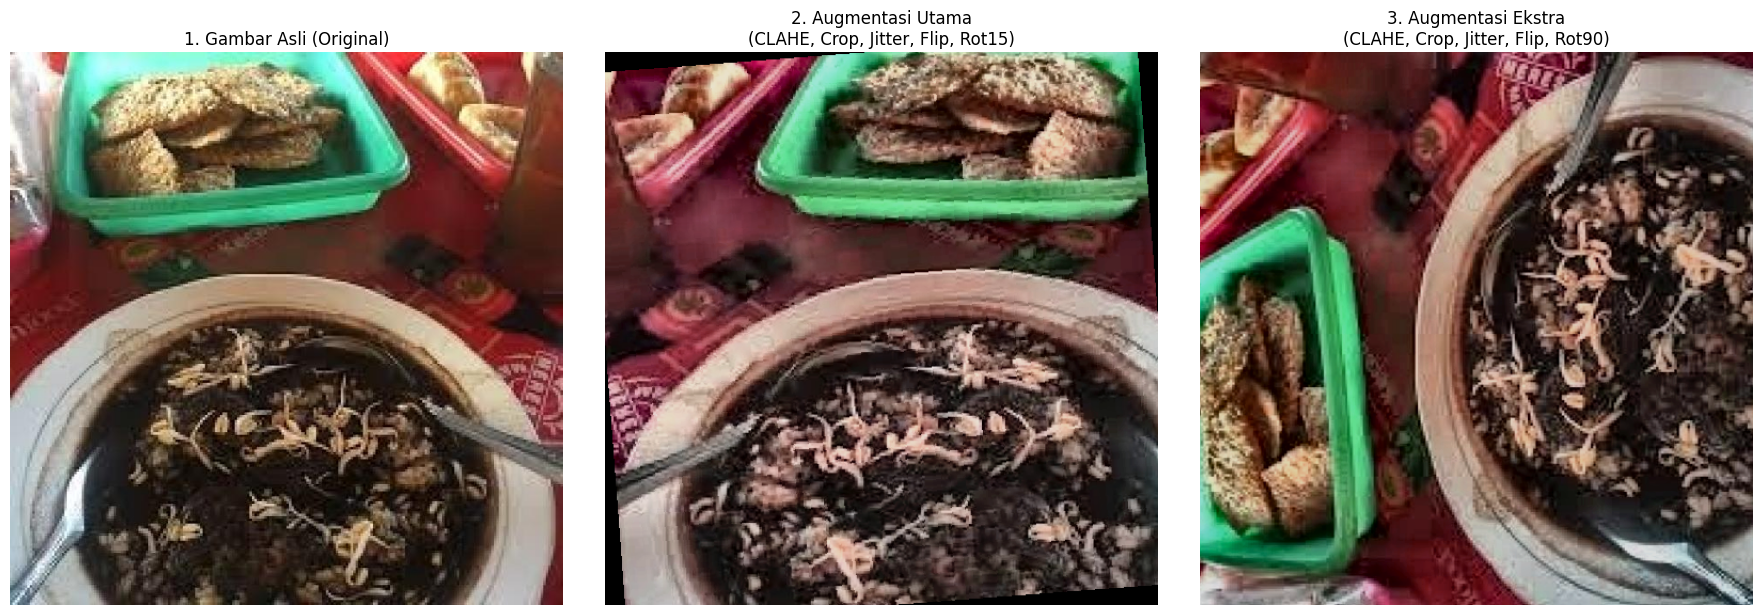

In [5]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
import random
import torch

# ===================================================================
# === BLOK VISUALISASI AUGMENTASI (Tambahan)
# ===================================================================
print("\n" + "#"*80)
print("### MEMBANDINGKAN GAMBAR ASLI vs. AUGMENTASI ###")
print("#"*80 + "\n")

def denormalize(tensor, mean, std):
    """
    Mengembalikan tensor gambar dari ternormalisasi (mean/std) ke [0, 1].
    """
    # Kloning agar tidak mengubah tensor asli
    tensor = tensor.clone() 
    
    # Buat tensor dari mean dan std, dan sesuaikan bentuknya
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    
    # Balikkan normalisasi: (tensor * std) + mean
    tensor.mul_(std).add_(mean)
    
    # Pastikan nilai tetap di [0, 1]
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

def visualize_augmentations(dataset_df, transform_main, transform_extra, mean, std):
    # 1. Ambil satu gambar acak dari dataset training Anda
    idx = random.randint(0, len(dataset_df) - 1)
    sample_row = dataset_df.iloc[idx]
    img_path = sample_row['Filepath']
    label = sample_row['Label']
    
    print(f"Menampilkan contoh untuk: {label} (dari {img_path})")

    # 2. Muat gambar asli
    original_pil_image = Image.open(img_path).convert('RGB')

    # 3. Terapkan transformasi
    # Ini akan menghasilkan tensor [C, H, W] yang sudah dinormalisasi
    transformed_main_tensor = transform_main(original_pil_image)
    transformed_extra_tensor = transform_extra(original_pil_image)

    # 4. De-normalisasi tensor agar bisa ditampilkan
    denorm_main_tensor = denormalize(transformed_main_tensor, mean, std)
    denorm_extra_tensor = denormalize(transformed_extra_tensor, mean, std)

    # 5. Konversi tensor kembali ke gambar PIL
    to_pil = ToPILImage()
    augmented_main_image = to_pil(denorm_main_tensor)
    augmented_extra_image = to_pil(denorm_extra_tensor)

    # 6. Plot semua 3 gambar
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    ax1.imshow(original_pil_image)
    ax1.set_title("1. Gambar Asli (Original)")
    ax1.axis('off')
    
    ax2.imshow(augmented_main_image)
    ax2.set_title("2. Augmentasi Utama\n(CLAHE, Crop, Jitter, Flip, Rot15)")
    ax2.axis('off')
    
    ax3.imshow(augmented_extra_image)
    ax3.set_title("3. Augmentasi Ekstra\n(CLAHE, Crop, Jitter, Flip, Rot90)")
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()

# --- Jalankan Visualisasi ---
try:
    # (Asumsi train_split, train_transform_main_518, train_transform_extra_518,
    #  IMAGENET_MEAN, dan IMAGENET_STD sudah ada di memori)
    visualize_augmentations(
        train_split, 
        train_transform,         
        train_transform_extra,
        IMAGENET_MEAN, 
        IMAGENET_STD
    )
except NameError as e:
    print(f"\n❌ GAGAL: Tidak bisa menjalankan visualisasi.")
    print(f"Error: {e}. Pastikan 'train_split' dan transforms sudah terdefinisi.")

## Model EVA

In [6]:
# ===================================================================
# === 1. TAMBAHKAN IMPORT INI DI BAGIAN ATAS SKRIP ANDA ===
# ===================================================================
from timm.data.mixup import Mixup
# (Asumsi impor lain seperti torch, timm, dll sudah ada)
# ...
import torch.nn.functional as F

###################################################################################
### BLOK B: MELATIH MODEL EVA TRANSFORMER (DENGAN MIXUP/CUTMIX)
###################################################################################
print("\n" + "#"*80)
print("### MEMULAI BLOK B: TRAINING MODEL EVA TRANSFORMER (MIXUP/CUTMIX) ###")
print("#"*80 + "\n")

# B.1. Konfigurasi khusus untuk Model EVA
IMG_SIZE = 224
BATCH_SIZE = 8
BEST_MODEL_NAME_EVA = "best_eva_standalone.pth" 
print(f"Menggunakan Ukuran Gambar: {IMG_SIZE}x{IMG_SIZE}, Batch Size: {BATCH_SIZE}")

# B.2. Buat Ulang Transforms dan DataLoaders
# (Tidak ada perubahan di sini, kode Anda sudah benar)
train_transform_main_224 = transforms.Compose([
    CLAHETransform(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD)
])
train_transform_extra_224 = transforms.Compose([
    CLAHETransform(),
    transforms.RandomChoice([transforms.RandomRotation((90, 90)), transforms.RandomRotation((-90, -90))]),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])
val_test_transform_224 = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])
train_dataset = DualTransformDataset(train_split, 'Filepath', 'Label', train_transform_main_224, train_transform_extra_224)
val_dataset = CustomDataset(val_split, 'Filepath', 'Label', val_test_transform_224)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True)


# B.3. Inisialisasi Model
class SingleEvaModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model("eva02_base_patch14_224", pretrained=True, num_classes=num_classes)
    def forward(self, x):
        return self.backbone(x)

model = SingleEvaModel(num_classes=len(label_mapping)).to(DEVICE)
print(f"Menggunakan model: eva02_base_patch14_224")

criterion = nn.CrossEntropyLoss(weight=class_weights,label_smoothing=0.1)

# --- TAMBAHKAN INISIALISASI MIXUP ---
print("Menginisialisasi Mixup/CutMix...")
mixup_fn = Mixup(
    mixup_alpha=0.8,    # Nilai standar timm
    cutmix_alpha=1.0,   # Nilai standar timm
    prob=1.0,           # Terapkan salah satu (mixup/cutmix) pada SETIAP batch
    switch_prob=0.5,    # 50% Mixup, 50% CutMix
    mode='batch',
    label_smoothing=0.1,# Selaras dengan criterion Anda
    num_classes=len(label_mapping)
)
# ------------------------------------

scaler = torch.amp.GradScaler()
best_f1 = 0.0
best_acc = 0.0

# B.4. Lakukan Training (3 Tahap disesuaikan untuk EVA)
# --- TAHAP 1 (Tidak Berubah) ---
print("\n" + "="*50 + "\nTAHAP 1 (EVA): Melatih Classifier Head\n" + "="*50)
for param in model.backbone.parameters(): param.requires_grad = False
for param in model.backbone.head.parameters(): param.requires_grad = True 
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_S1)
for epoch in range(EPOCHS_S1):
    model.train()
    progress_bar = tqdm(train_loader, desc=f"S1 EVA Epoch {epoch+1}/{EPOCHS_S1}")
    for images, labels in progress_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        # --- PERBAIKAN: Jangan gunakan Mixup di Tahap 1 ---
        # Kita ingin head belajar pemetaan sederhana terlebih dahulu
        
        optimizer.zero_grad()
        with torch.amp.autocast(device_type = 'cuda'):
            # CrossEntropyLoss TIDAK bisa menangani label [B] dan smoothing
            # Jadi kita harus membuatnya one-hot manual untuk Tahap 1 & 2
            labels_one_hot = F.one_hot(labels, num_classes=len(label_mapping)).float()
            outputs = model(images); loss = criterion(outputs, labels_one_hot)
            
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()

# --- TAHAP 2 (Tidak Berubah) ---
print("\n" + "="*50 + "\nTAHAP 2 (EVA): Melatih Head + Blok Atas\n" + "="*50)
for param in model.backbone.blocks[-1].parameters(): param.requires_grad = True
for param in model.backbone.norm.parameters(): param.requires_grad = True
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_S2)
for epoch in range(EPOCHS_S2):
    model.train()
    progress_bar = tqdm(train_loader, desc=f"S2 EVA Epoch {epoch+1}/{EPOCHS_S2}")
    for images, labels in progress_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        with torch.amp.autocast(device_type = 'cuda'):
            # Gunakan one-hot yang sama
            labels_one_hot = F.one_hot(labels, num_classes=len(label_mapping)).float()
            outputs = model(images); loss = criterion(outputs, labels_one_hot)
            
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        
# --- TAHAP 3 (DIMODIFIKASI) ---

# --- REKOMENDASI: TAMBAHKAN EPOCH KARENA MIXUP ---
EPOCHS_S3_MIXUP = 15 # Coba 25-30 epoch, karena Mixup butuh waktu lebih lama
print(f"TAHAP 3 akan berjalan selama {EPOCHS_S3_MIXUP} epochs (lebih lama untuk Mixup/CutMix)")
# -------------------------------------------------

LR_S3_EVA = 1e-5 
print("\n" + "="*50 + "\nTAHAP 3 (EVA): Fine-tuning Seluruh Model (dengan Mixup/CutMix)\n" + "="*50)
for param in model.parameters(): param.requires_grad = True
optimizer = optim.AdamW(model.parameters(), lr=LR_S3_EVA, weight_decay=1e-4)

# --- SESUAIKAN T_max DENGAN EPOCH BARU ---
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_S3_MIXUP, # <-- GANTI
    eta_min=1e-6    
)
# ----------------------------------------

for epoch in range(EPOCHS_S3_MIXUP): # <-- GANTI
    model.train()
    train_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"S3 EVA Epoch {epoch+1}/{EPOCHS_S3_MIXUP} (Train)") # <-- GANTI
    for images, labels in train_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        # --- TERAPKAN MIXUP/CUTMIX DI SINI ---
        images, labels = mixup_fn(images, labels)
        # 'labels' sekarang menjadi [B, N_CLASSES] (soft labels)
        # ------------------------------------
        
        optimizer.zero_grad()
        with torch.amp.autocast(device_type = 'cuda'):
            outputs = model(images)
            # 'criterion' bisa langsung menangani 'labels' soft [B, N_CLASSES]
            loss = criterion(outputs, labels) 
            
        scaler.scale(loss).backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        # scheduler.step() # <-- HAPUS DARI SINI
        train_loss += loss.item()
    
    # --- PINDAHKAN SCHEDULER.STEP() KE SINI ---
    # Panggil scheduler HANYA sekali per epoch
    scheduler.step()
    # ---------------------------------------

    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast(device_type = 'cuda'):
                # Untuk validasi, kita gunakan label asli (hard labels)
                # jadi kita TIDAK perlu one-hot
                outputs = model(images)
                loss = criterion(outputs, labels) # <-- 'labels' di sini [B]
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy()); all_labels.extend(labels.cpu().numpy())
            
    f1 = f1_score(all_labels, all_preds, average="macro")
    acc = accuracy_score(all_labels, all_preds) 
    
    # Opsi: Tampilkan LR saat ini untuk memverifikasi
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch [{epoch+1}/{EPOCHS_S3_MIXUP}] | LR: {current_lr:.2e} | Val F1: {f1:.4f}| Val acc: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), BEST_MODEL_NAME_EVA) 
        print(f"✅ Model EVA disimpan ke {BEST_MODEL_NAME_EVA} (acc terbaik baru: {best_acc:.4f})") 

print(f"\nTraining Model EVA Selesai. Bobot terbaik disimpan di {BEST_MODEL_NAME_EVA}") 



################################################################################
### MEMULAI BLOK B: TRAINING MODEL EVA TRANSFORMER (MIXUP/CUTMIX) ###
################################################################################

Menggunakan Ukuran Gambar: 224x224, Batch Size: 8


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Menggunakan model: eva02_base_patch14_224
Menginisialisasi Mixup/CutMix...

TAHAP 1 (EVA): Melatih Classifier Head


S1 EVA Epoch 1/3:   0%|          | 0/811 [00:00<?, ?it/s]

S1 EVA Epoch 2/3:   0%|          | 0/811 [00:00<?, ?it/s]

...


Epoch [13/15] | LR: 1.39e-06 | Val F1: 0.9533| Val acc: 0.9531


S3 EVA Epoch 14/15 (Train):   0%|          | 0/811 [00:00<?, ?it/s]


Epoch [14/15] | LR: 1.10e-06 | Val F1: 0.9484| Val acc: 0.9482


S3 EVA Epoch 15/15 (Train):   0%|          | 0/811 [00:00<?, ?it/s]


Epoch [15/15] | LR: 1.00e-06 | Val F1: 0.9535| Val acc: 0.9531

Training Model EVA Selesai. Bobot terbaik disimpan di best_eva_standalone.pth


## Ensembeling model 


In [7]:
# ===================================================================
# === 2. KONFIGURASI DAN SETUP ===
# ===================================================================
# Direktori
TRAIN_DIR = "/kaggle/input/datasets/mdzkhkm/dataset-makanan/makanan"

# Konfigurasi Model dan Training
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 518
BATCH_SIZE = 8
NUM_WORKERS = os.cpu_count()

# --- HYPERPARAMETER UNTUK GRADUAL UNFREEZING ---
EPOCHS_S1 = 3
LR_S1 = 3e-4
EPOCHS_S2 = 5
LR_S2 = 5e-5
EPOCHS_S3 = 12
LR_S3 = 1.59e-06

# Statistik ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"Menggunakan device: {DEVICE}")
print(f"Ukuran gambar: {IMG_SIZE}x{IMG_SIZE}, Batch Size: {BATCH_SIZE}")

# ===================================================================
# === 3. FUNGSI DAN KELAS HELPER ===
# ===================================================================
def convert_path_to_df(dataset):
    image_dir = Path(dataset)
    
    # 1. Tentukan ekstensi gambar yang valid (dalam huruf kecil)
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff'}

    # 2. Ambil semua file path terlebih dahulu
    all_filepaths = list(image_dir.glob(r'**/*.*'))
    
    # 3. Filter daftar file, hanya ambil yang ekstensinya ada di set
    filepaths = [p for p in all_filepaths if p.suffix.lower() in image_extensions]
    
    # Cek jika tidak ada gambar yang ditemukan
    if not filepaths:
        print(f"Peringatan: Tidak ada file gambar yang ditemukan di {image_dir}")
        return pd.DataFrame(columns=['Filepath', 'Label'])

    # 4. Buat DataFrame
    labels = [p.parts[-2] for p in filepaths]
    filepaths = pd.Series(filepaths, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')
    return pd.concat([filepaths, labels], axis=1)

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_column, label_column=None, transform=None):
        self.dataframe = dataframe
        self.image_column = image_column
        self.label_column = label_column
        self.transform = transform
        
    def __len__(self): 
        return len(self.dataframe)
        
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx][self.image_column]
        image = Image.open(img_path).convert('RGB')
        if self.transform: 
            image = self.transform(image)
        if self.label_column:
            label = self.dataframe.iloc[idx][self.label_column]
            return image, torch.tensor(label, dtype=torch.long)
        return image

class DualTransformDataset(Dataset):
    def __init__(self, dataframe, image_column, label_column, transform_main, transform_extra):
        self.dataframe = dataframe
        self.image_column = image_column
        self.label_column = label_column
        self.transform_main = transform_main
        self.transform_extra = transform_extra

    def __len__(self):
        # Gandakan ukuran dataset (dua versi per gambar)
        return len(self.dataframe) * 2

    def __getitem__(self, idx):
        # Tentukan apakah pakai augmentasi utama atau tambahan
        base_idx = idx // 2
        use_extra = idx % 2 == 1

        row = self.dataframe.iloc[base_idx]
        img_path = row[self.image_column]
        label = torch.tensor(row[self.label_column], dtype=torch.long)

        image = Image.open(img_path).convert('RGB')

        if use_extra:
            image = self.transform_extra(image)
        else:
            image = self.transform_main(image)

        return image, label

class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    def __call__(self, img):
        img_np = np.array(img); img_lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2Lab)
        l, a, b = cv2.split(img_lab); l_clahe = self.clahe.apply(l)
        img_lab_clahe = cv2.merge((l_clahe, a, b))
        img_rgb_clahe = cv2.cvtColor(img_lab_clahe, cv2.COLOR_Lab2RGB)
        return Image.fromarray(img_rgb_clahe)


# ===================================================================
# === 4. PERSIAPAN DATA DENGAN STRATEGI "FIXED SPLIT" ===
# ===================================================================

# --- Langkah 4.1: Memuat data training ---
train_df = convert_path_to_df(TRAIN_DIR)
print(f"Jumlah total data training: {len(train_df)}")

# --- Langkah 4.2: Pemetaan Label ---
label_mapping = {
    "Ayam Bakar": 0,
    "Ayam Betutu": 1,
    "Ayam Goreng": 2,
    "Ayam Pop": 3,
    "Bakso": 4,
    "Coto Makassar": 5,
    "Gado Gado": 6,
    "Gudeg": 7,
    "Nasi Goreng": 8,
    "Pempek": 9,
    "Rawon": 10,
    "Rendang": 11,
    "Sate Madura": 12,
    "Sate Padang": 13,
    "Soto": 14
}

train_df['Label'] = train_df['Label'].map(label_mapping)

# Drop data jika ada label yang tidak dikenali, dan pastikan tipe data integer
train_df = train_df.dropna(subset=['Label'])
train_df['Label'] = train_df['Label'].astype(int)

# --- Langkah 4.3: Split Data ---
print("\nMenerapkan stratify dan fixed split...")
train_split, val_split = train_test_split(
    train_df, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_df['Label']
)

# Reset index
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

print(f"Ukuran set training final: {len(train_split)}")
print(f"Ukuran set validasi: {len(val_split)}")
print("="*50 + "\n")

# --- Langkah 4.4: Lanjutkan dengan pipeline seperti biasa ---
train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD)
])

# Transform tambahan: rotasi 90° kiri/kanan
train_transform_extra = transforms.Compose([
    CLAHETransform(),
    transforms.RandomChoice([
        transforms.RandomRotation((90, 90)),
        transforms.RandomRotation((-90, -90))
    ]),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = DualTransformDataset(
    train_split,
    image_column='Filepath',
    label_column='Label',
    transform_main=train_transform,
    transform_extra=train_transform_extra
)

val_dataset = CustomDataset(val_split, 'Filepath', 'Label', val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True)

# Hitung Class Weights
class_weights = compute_class_weight("balanced", classes=np.unique(train_split["Label"]), y=train_split["Label"])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

Menggunakan device: cuda
Ukuran gambar: 518x518, Batch Size: 8
Jumlah total data training: 4052

Menerapkan stratify dan fixed split...
Ukuran set training final: 3241
Ukuran set validasi: 811



In [8]:
class SingleEVAModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        # Menggunakan model EVA-02 yang sangat kuat
        model_name = "eva02_base_patch14_224.mim_in22k"
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    def forward(self, x):
        return self.backbone(x)

In [9]:
!pip install ttach

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import ttach as tta
import pandas as pd
import os
import timm # Pastikan timm diimpor
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, accuracy_score

# =================================================================================
# ASUMSI: Variabel global (DEVICE, label_mapping, TEST_DIR, BATCH_SIZE, dll.)
# dan DataFrame (val_split) sudah ada dari blok sebelumnya.
# =Goodle=================================================================


####################################################################################
### BLOK C: FINAL ENSEMBLE INFERENCE (DINO-518, EVA-224, EVA-384)
####################################################################################

print("\n" + "#"*80)
print("### MEMULAI BLOK C: ENSEMBLE (DINO-518, EVA-224) ###")
print("#"*80 + "\n")

# C.1. Definisikan TTA transformations
print("Mendefinisikan TTA transforms (Flip + Rotasi)...")
tta_transforms = tta.Compose(
    [
        tta.HorizontalFlip(),
        tta.Rotate90(angles=[0, 90, 180, 270]), 
    ]
)

# C.2. Buat Wrapper Model untuk resizing
class Model224Wrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        print(" > Wrapper 224px dibuat")

    def forward(self, x_518):
        # Downsample 518 -> 224
        x_224 = F.interpolate(x_518, size=(224, 224), mode='bilinear', align_corners=False)
        return self.model(x_224)


# --- Tambahkan Definisi Model yang Dibutuhkan ---
class SingleDINOv2Model(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        # Asumsi model DINO dilatih pada 518px (sesuai skrip Fusion asli)
        self.backbone = timm.create_model(
            "vit_base_patch14_dinov2", 
            pretrained=False, 
            num_classes=num_classes, 
            img_size=518 
        )
    def forward(self, x):
        return self.backbone(x)

class SingleEvaModel(nn.Module):
    def __init__(self, num_classes=5, img_size=224): # Jadikan img_size parameter
        super().__init__()
        self.backbone = timm.create_model(
            "eva02_base_patch14_224", 
            pretrained=False, 
            num_classes=num_classes,
            img_size=img_size # <-- Gunakan parameter img_size
        )
    def forward(self, x):
        return self.backbone(x)
# ---------------------------------------------

# C.3. Inisialisasi model ASLI
print("\nInisialisasi model dasar...")
model_dino_base = SingleDINOv2Model(num_classes=len(label_mapping)).to(DEVICE)
model_eva224_base = SingleEvaModel(num_classes=len(label_mapping), img_size=224).to(DEVICE)

# C.4. Muat bobot ke model ASLI
print("Memuat bobot...")

# !!! GANTI PATH INI ke lokasi file bobot SingleDINOv2 Anda !!!
DINO_MODEL_PATH = "/kaggle/working/best_dinov2_standalone.pth" 
print(f"Memuat Model 1 (SingleDINOv2 @ 518px) dari: {DINO_MODEL_PATH}")
model_dino_base.load_state_dict(torch.load(DINO_MODEL_PATH, map_location=DEVICE))

# Path ini dari kode Anda sebelumnya
EVA224_MODEL_PATH = "/kaggle/working/best_eva_standalone.pth"
print(f"Memuat Model 2 (SingleEVA @ 224px) dari: {EVA224_MODEL_PATH}")
model_eva224_base.load_state_dict(torch.load(EVA224_MODEL_PATH, map_location=DEVICE))



# C.5. BUNGKUS model dengan TTA
print("\nMembungkus model dengan TTA Wrapper...")
# Model DINO (518px) tidak perlu wrapper, input sudah 518px
tta_model_dino = tta.ClassificationTTAWrapper(model_dino_base, tta_transforms).to(DEVICE)

# Model EVA (224px) perlu downsample 518 -> 224
tta_model_eva224 = tta.ClassificationTTAWrapper(Model224Wrapper(model_eva224_base), tta_transforms).to(DEVICE)

# Set semua model TTA ke mode eval
tta_model_dino.eval()
tta_model_eva224.eval()
print("Semua 3 model siap untuk TTA.")

# C.6. Transformasi Test
final_test_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((518, 518)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

# =============================================================================
# === C.VAL: VALIDASI ENSEMBLE PADA VALIDATION SET
# =============================================================================
print("\n" + "="*50)
print("### MENJALANKAN VALIDASI ENSEMBLE PADA VAL SET ###")
print("="*50)

# C.VAL.1. Fungsi Helper untuk Evaluasi
def evaluate_ensemble(name, prob_list, true_labels_np):
    avg_probs = torch.stack(prob_list).mean(dim=0)
    final_preds = torch.argmax(avg_probs, dim=1).numpy()
    f1 = f1_score(true_labels_np, final_preds, average="macro")
    acc = accuracy_score(true_labels_np, final_preds)
    print(f"| {name.ljust(30)} | {f1:.6f} | {acc:.6f} |")
    return (name, f1, acc)

try:
    # C.VAL.2. Buat Val Loader
    val_dataset_tta = CustomDataset(val_split, 'Filepath', 'Label', final_test_transform)
    val_loader_tta = DataLoader(val_dataset_tta, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    all_val_probs_dino, all_val_probs_eva224 = [], []
    all_val_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader_tta, desc="Validasi TTA Ensemble"):
            images_518 = images.to(DEVICE)
            
            probs_dino = tta_model_dino(images_518)
            probs_eva224 = tta_model_eva224(images_518)

            all_val_probs_dino.append(probs_dino.cpu())
            all_val_probs_eva224.append(probs_eva224.cpu())
            all_val_labels.append(labels.cpu())

    # C.VAL.3. Gabungkan Batch
    all_val_probs_dino = torch.cat(all_val_probs_dino, dim=0)
    all_val_probs_eva224 = torch.cat(all_val_probs_eva224, dim=0)
    all_val_labels_np = torch.cat(all_val_labels, dim=0).numpy()

    # C.VAL.4. Tampilkan Tabel Perbandingan (Simple Averaging)
    print("\n--- HASIL VALIDASI TTA ENSEMBLE (SIMPLE AVERAGING) ---")
    print("| Model Combination                | F1-Macro | Accuracy |")
    print("|----------------------------------|----------|----------|")
    
    results = []
    
    # Model Tunggal
    results.append(evaluate_ensemble("Model DINO-518", [all_val_probs_dino], all_val_labels_np))
    results.append(evaluate_ensemble("Model EVA-224", [all_val_probs_eva224], all_val_labels_np))
    print("|----------------------------------|----------|----------|")

    # Kombinasi 2 Model
    results.append(evaluate_ensemble("DINO + EVA-224", [all_val_probs_dino, all_val_probs_eva224], all_val_labels_np))

    # Temukan yang terbaik
    best_result = sorted(results, key=lambda x: x[2], reverse=True)[0]
    print(f"\nKombinasi Terbaik (Simple Avg): {best_result[0]} (Acc: {best_result[2]:.6f})")
    
except Exception as e:
    print(f" GAGAL: Tidak bisa menjalankan validasi. Error: {e}")
  


################################################################################
### MEMULAI BLOK C: ENSEMBLE (DINO-518, EVA-224) ###
################################################################################

Mendefinisikan TTA transforms (Flip + Rotasi)...

Inisialisasi model dasar...
Memuat bobot...
Memuat Model 1 (SingleDINOv2 @ 518px) dari: /kaggle/working/best_dinov2_standalone.pth
Memuat Model 2 (SingleEVA @ 224px) dari: /kaggle/working/best_eva_standalone.pth

Membungkus model dengan TTA Wrapper...
 > Wrapper 224px dibuat
Semua 3 model siap untuk TTA.

### MENJALANKAN VALIDASI ENSEMBLE PADA VAL SET ###


Validasi TTA Ensemble:   0%|          | 0/102 [00:00<?, ?it/s]


--- HASIL VALIDASI TTA ENSEMBLE (SIMPLE AVERAGING) ---
| Model Combination                | F1-Macro | Accuracy |
|----------------------------------|----------|----------|
| Model DINO-518                 | 0.956493 | 0.955610 |
| Model EVA-224                  | 0.952258 | 0.951911 |
|----------------------------------|----------|----------|
| DINO + EVA-224                 | 0.962525 | 0.961776 |

Kombinasi Terbaik (Simple Avg): DINO + EVA-224 (Acc: 0.961776)



### MEMBANDINGKAN CONFUSION MATRIX (ENSEMBLE NON-TTA vs TTA) ###

Menghitung prediksi Ensemble TANPA TTA...


Inferensi Non-TTA:   0%|          | 0/102 [00:00<?, ?it/s]

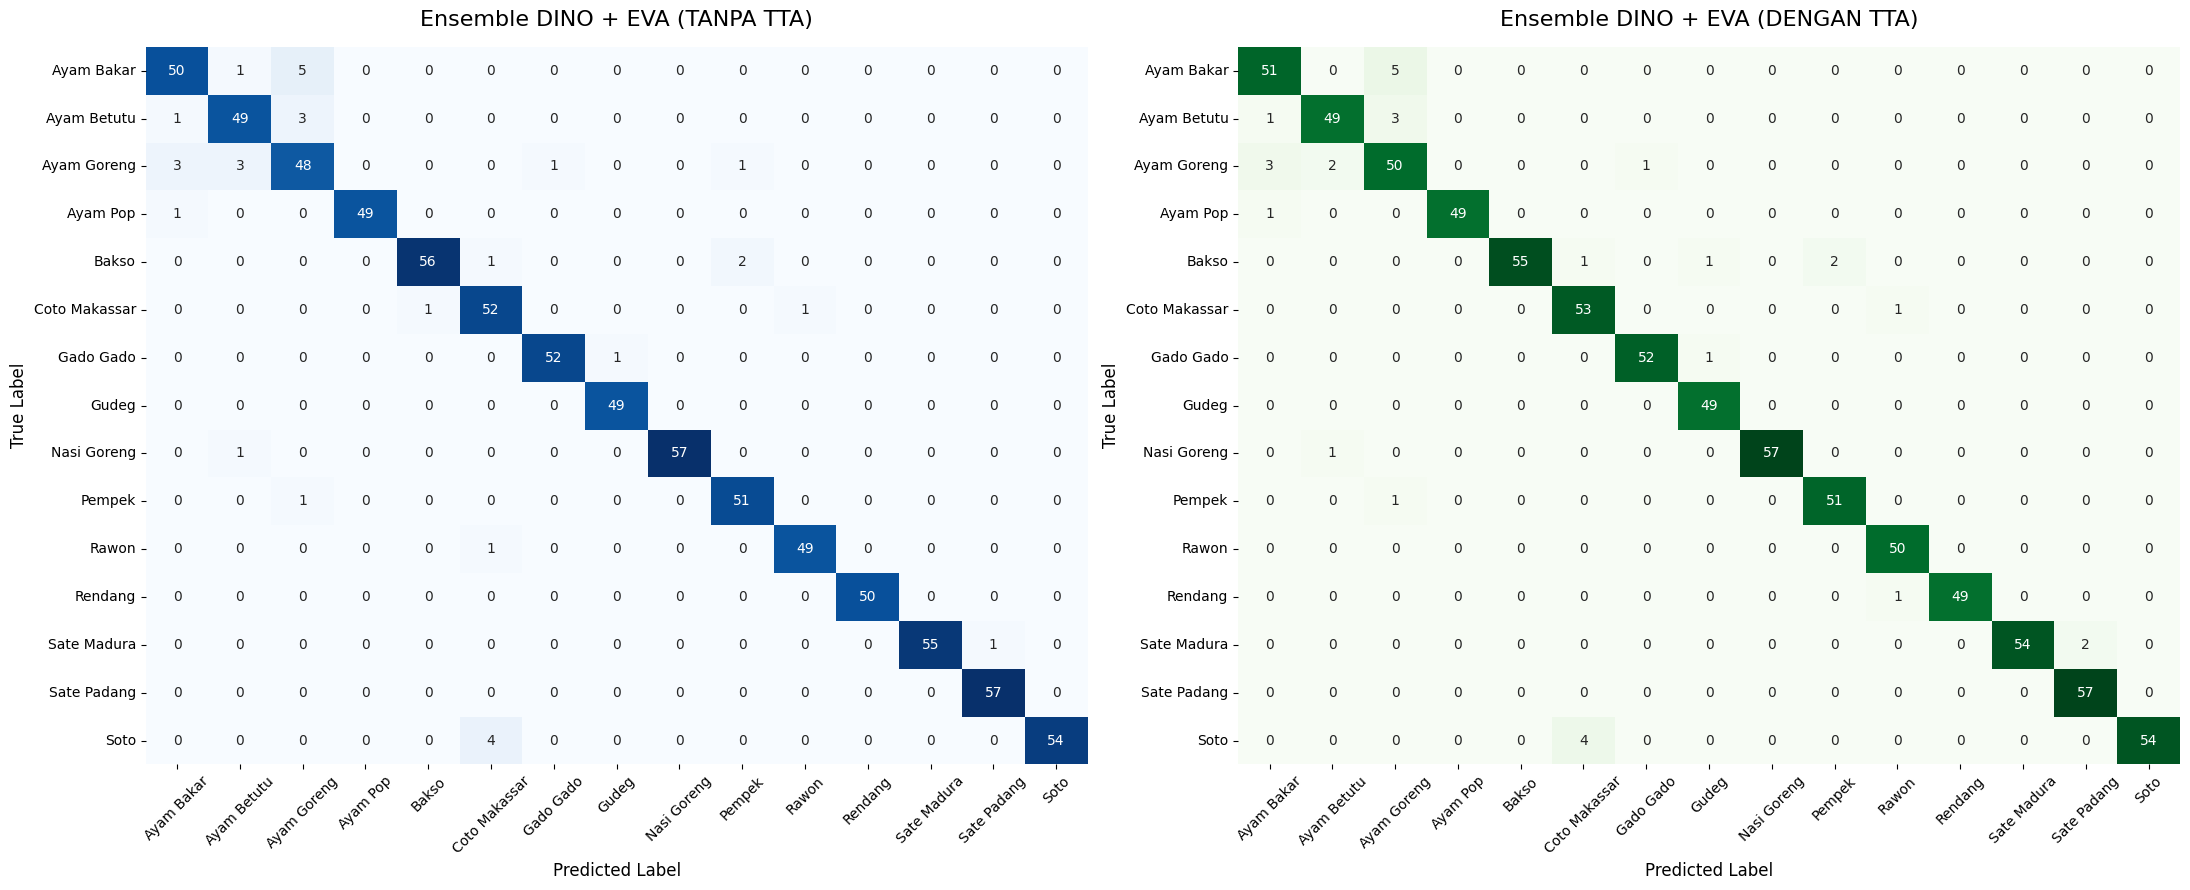


--------------------------------------------------
📈 F1-Macro Non-TTA : 0.960101
📈 F1-Macro TTA     : 0.962525
Selisih Peningkatan: +0.002424
--------------------------------------------------


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
import torch.nn.functional as F

# =============================================================================
# === BLOK VISUALISASI: CONFUSION MATRIX (NON-TTA vs TTA)
# =============================================================================
print("\n" + "="*80)
print("### MEMBANDINGKAN CONFUSION MATRIX (ENSEMBLE NON-TTA vs TTA) ###")
print("="*80 + "\n")

# 1. Pastikan model dasar dalam mode evaluasi
model_dino_base.eval()
model_eva224_base.eval()

all_val_probs_dino_notta = []
all_val_probs_eva224_notta = []
all_val_labels_cm = []

print("Menghitung prediksi Ensemble TANPA TTA...")
with torch.no_grad():
    for images, labels in tqdm(val_loader_tta, desc="Inferensi Non-TTA"):
        images_518 = images.to(DEVICE)
        # Downsample untuk EVA
        images_224 = F.interpolate(images_518, size=(224, 224), mode='bilinear', align_corners=False)
        
        with torch.amp.autocast(device_type='cuda' if 'cuda' in DEVICE.type else 'cpu'):
            logits_dino = model_dino_base(images_518)
            logits_eva = model_eva224_base(images_224)
            
        # Terapkan Softmax karena base model mengembalikan raw logits
        probs_dino = torch.softmax(logits_dino, dim=1)
        probs_eva = torch.softmax(logits_eva, dim=1)
        
        all_val_probs_dino_notta.append(probs_dino.cpu())
        all_val_probs_eva224_notta.append(probs_eva.cpu())
        all_val_labels_cm.append(labels.cpu())

# Gabungkan batch Non-TTA
all_val_probs_dino_notta = torch.cat(all_val_probs_dino_notta, dim=0)
all_val_probs_eva224_notta = torch.cat(all_val_probs_eva224_notta, dim=0)
all_val_labels_cm = torch.cat(all_val_labels_cm, dim=0).numpy()

# 2. Hitung Prediksi Akhir (Averaging)
# --- NON-TTA ---
avg_probs_notta = (all_val_probs_dino_notta + all_val_probs_eva224_notta) / 2.0
preds_notta = torch.argmax(avg_probs_notta, dim=1).numpy()

# --- TTA (Mengambil dari memori variabel cell sebelumnya) ---
avg_probs_tta = (all_val_probs_dino + all_val_probs_eva224) / 2.0
preds_tta = torch.argmax(avg_probs_tta, dim=1).numpy()

# 3. Buat Confusion Matrix
cm_notta = confusion_matrix(all_val_labels_cm, preds_notta)
cm_tta = confusion_matrix(all_val_labels_cm, preds_tta)

# Ambil nama kelas secara berurutan
class_names = [k for k, v in sorted(label_mapping.items(), key=lambda item: item[1])]

# 4. Visualisasi dengan Seaborn Heatmap
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Plot Non-TTA
sns.heatmap(cm_notta, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[0].set_title('Ensemble DINO + EVA (TANPA TTA)', fontsize=16, pad=15)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot TTA
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[1].set_title('Ensemble DINO + EVA (DENGAN TTA)', fontsize=16, pad=15)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Tampilkan ringkasan metrik
f1_notta = f1_score(all_val_labels_cm, preds_notta, average="macro")
f1_tta = f1_score(all_val_labels_cm, preds_tta, average="macro")

print("\n" + "-"*50)
print(f"📈 F1-Macro Non-TTA : {f1_notta:.6f}")
print(f"📈 F1-Macro TTA     : {f1_tta:.6f}")
print(f"Selisih Peningkatan: {f1_tta - f1_notta:+.6f}")
print("-"*50)